Purpose: Find clock- and light-regulation-related genes & plot their TPM profiles by physiotype to see if any appear variable.<br>
Author: Anna Pardo<br>
Date initiated: June 10, 2026

In [1]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

## Section 1: Find clock-related gene IDs in Yuccas

In [18]:
# make a JSON of Arabidopsis clock/light genes (just generally genes of interest)
# clock genes reference: https://cshperspectives.cshlp.org/content/8/12/a027748/F1.large.jpg
# database queried: arabidopsis.org (TAIR)
# also includes some genes we know are of interest from prior investigation of our maSigPro DE, etc.
at_circlight = {
    "TOC1":"AT5G61380",
    "LNK2":"AT3G54500",
    "CCA1":"AT2G46830",
    "LHY":"AT1G01060",
    "PRR9":"AT2G46790",
    "PRR7":"AT5G02810",
    "PRR5":"AT5G24470",
    "ELF4":"AT2G40080",
    "LUX":"AT3G46640",
    "ELF3":"AT2G25930",
    "EID1":"AT4G02440",
    "GI":"AT1G22770"
}

In [6]:
# load orthogroup info
ogs = pd.read_csv("/home/leviathan22/Yucca_genomics/Orthogroups-Yucca_v3_7Oct2025.tsv",sep="\t",header="infer",
                 usecols=["Orthogroup","Arabidopsis_thaliana","Yucca_aloifolia","Yucca_filamentosa_v3"])
ogs.head()

/tmp/ipykernel_316/1459656482.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  ogs = pd.read_csv("/home/leviathan22/Yucca_genomics/Orthogroups-Yucca_v3_7Oct2025.tsv",sep="\t",header="infer",


,Orthogroup,Arabidopsis_thaliana,Yucca_aloifolia,Yucca_filamentosa_v3
0,OG0000000,NaN,NaN,NaN
1,OG0000001,NaN,NaN,NaN
2,OG0000002,NaN,NaN,"YufilH1005191m, YufilH1008745m"
3,OG0000003,NaN,NaN,NaN
4,OG0000004,"AT1G48980.1, AT2G17970.1, AT4G36090.3","Yucal.03G026500.1.p, Yucal.03G026600.1.p, Yuca...","YufilH1017244m, YufilH1017245m, YufilH1017246m..."


In [7]:
ogs.dropna(subset=["Arabidopsis_thaliana"],inplace=True)
ogs.head()

,Orthogroup,Arabidopsis_thaliana,Yucca_aloifolia,Yucca_filamentosa_v3
4,OG0000004,"AT1G48980.1, AT2G17970.1, AT4G36090.3","Yucal.03G026500.1.p, Yucal.03G026600.1.p, Yuca...","YufilH1017244m, YufilH1017245m, YufilH1017246m..."
5,OG0000005,"AT1G06180.1, AT1G16490.1, AT1G22640.1, AT1G346...","Yucal.01G220700.1.p, Yucal.01G296700.1.p, Yuca...","YufilH1005218m, YufilH1005219m, YufilH1006851m..."
6,OG0000006,ATMG00750.1,NaN,NaN
7,OG0000007,"AT1G11610.2, AT1G13080.1, AT1G13090.1, AT1G131...","Yucal.01G102400.1.p, Yucal.01G102500.1.p, Yuca...","YufilH1002344m, YufilH1002345m, YufilH1002346m..."
9,OG0000009,"AT3G47090.1, AT3G47110.1, AT3G47570.1, AT3G475...","Yucal.04G189600.1.p, Yucal.04G199600.1.p, Yuca...","YufilH1027659m, YufilH1027664m, YufilH1027665m..."


In [19]:
# re-format dict into dataframe
dfdict = {"gene_name":at_circlight.keys(),"GeneID_At":at_circlight.values()}
atcl_df = pd.DataFrame(dfdict)
atcl_df.head()

,gene_name,GeneID_At
0,TOC1,AT5G61380
1,LNK2,AT3G54500
2,CCA1,AT2G46830
3,LHY,AT1G01060
4,PRR9,AT2G46790


In [13]:
# find a list of orthogroups for a given Arabidopsis gene 
def find_orthogroups(gid):
    oglist = []
    for i in range(len(ogs.index)):
        if gid in ogs.iloc[i,1]:
            oglist.append(ogs.iloc[i,0])
    if len(oglist) > 1:
        return oglist
    elif len(oglist)==1:
        return oglist[0]
    else:
        return "No orthogroup found"

In [20]:
ogl = []
for i in range(len(atcl_df.index)):
    ogl.append(find_orthogroups(atcl_df.iloc[i,1]))
atcl_df["Orthogroup"] = ogl
atcl_df.head()

,gene_name,GeneID_At,Orthogroup
0,TOC1,AT5G61380,OG0002937
1,LNK2,AT3G54500,OG0001574
2,CCA1,AT2G46830,OG0001692
3,LHY,AT1G01060,OG0001692
4,PRR9,AT2G46790,OG0002802


In [21]:
atcl_df = atcl_df.merge(ogs)
atcl_df

,gene_name,GeneID_At,Orthogroup,Arabidopsis_thaliana,Yucca_aloifolia,Yucca_filamentosa_v3
0,TOC1,AT5G61380,OG0002937,AT5G61380.1,"Yucal.11G006100.1.p, Yucal.15G098200.1.p, Yuca...","YufilH1057026m, YufilH1057027m, YufilH1070906m..."
1,LNK2,AT3G54500,OG0001574,AT3G54500.3,"Yucal.01G204800.1.p, Yucal.02G286000.1.p, Yuca...","YufilH1004829m, YufilH1004830m, YufilH1004831m..."
2,CCA1,AT2G46830,OG0001692,"AT1G01060.1, AT2G46830.1","Yucal.11G020800.1.p, Yucal.15G077900.1.p, Yuca...","YufilH1057345m, YufilH1057346m, YufilH1057347m..."
3,LHY,AT1G01060,OG0001692,"AT1G01060.1, AT2G46830.1","Yucal.11G020800.1.p, Yucal.15G077900.1.p, Yuca...","YufilH1057345m, YufilH1057346m, YufilH1057347m..."
4,PRR9,AT2G46790,OG0002802,"AT2G46790.1, AT5G24470.1","Yucal.11G000300.1.p, Yucal.21G000500.1.p","YufilH1056883m, YufilH1056884m, YufilH1056885m..."
5,PRR5,AT5G24470,OG0002802,"AT2G46790.1, AT5G24470.1","Yucal.11G000300.1.p, Yucal.21G000500.1.p","YufilH1056883m, YufilH1056884m, YufilH1056885m..."
6,PRR7,AT5G02810,OG0001046,"AT5G02810.1, AT5G60100.2","Yucal.10G149200.1.p, Yucal.26G049600.1.p","YufilH1014209m, YufilH1014210m, YufilH1014211m..."
7,ELF4,AT2G40080,OG0031772,AT2G40080.1,NaN,NaN
8,LUX,AT3G46640,OG0006892,"AT3G46640.3, AT5G59570.1","Yucal.02G227100.1.p, Yucal.26G061100.1.p","YufilH1013881m, YufilH1090794m"
9,ELF3,AT2G25930,OG0002589,"AT2G25930.1, AT3G21320.1","Yucal.01G088400.1.p, Yucal.06G061900.1.p, Yuca...","YufilH1002011m, YufilH1002012m, YufilH1002013m..."


In [17]:
type(atcl_df.iloc[0,4])

str

In [39]:
# set up a dataframe with columns = GeneID (append Ya & Yf), Orthogroup, Gene Name 
## note some gene names will be together (CCA1/LHY & PRR5/PRR9)

def expand_og_genelist(og,spcol):
    df = atcl_df[atcl_df["Orthogroup"]==og]
    df = df[["gene_name","Orthogroup",spcol]]
    
    # get gene name(s)
    if len(df.index)>1:
        gnlist = list(df["gene_name"])
        gname = ""
        for i in gnlist:
            gname = gname+i+"/"
        gname = gname.rstrip("/")
    else:
        gname = df.iloc[0,0]
        
    df = df[["Orthogroup",spcol]].drop_duplicates()
    gids = df.iloc[0,1].split(", ")
    if "aloifolia" in spcol:
        gids = [i.rstrip(".1.p")+".v2.1" for i in gids]
    else:
        gids = [i+".g" for i in gids]
    
    dfdict = {"GeneID":gids,"Orthogroup":og,"gene_name":gname}
        
    return pd.DataFrame(dfdict)

In [41]:
atcl_df = atcl_df.dropna()
atcl_df

,gene_name,GeneID_At,Orthogroup,Arabidopsis_thaliana,Yucca_aloifolia,Yucca_filamentosa_v3
0,TOC1,AT5G61380,OG0002937,AT5G61380.1,"Yucal.11G006100.1.p, Yucal.15G098200.1.p, Yuca...","YufilH1057026m, YufilH1057027m, YufilH1070906m..."
1,LNK2,AT3G54500,OG0001574,AT3G54500.3,"Yucal.01G204800.1.p, Yucal.02G286000.1.p, Yuca...","YufilH1004829m, YufilH1004830m, YufilH1004831m..."
2,CCA1,AT2G46830,OG0001692,"AT1G01060.1, AT2G46830.1","Yucal.11G020800.1.p, Yucal.15G077900.1.p, Yuca...","YufilH1057345m, YufilH1057346m, YufilH1057347m..."
3,LHY,AT1G01060,OG0001692,"AT1G01060.1, AT2G46830.1","Yucal.11G020800.1.p, Yucal.15G077900.1.p, Yuca...","YufilH1057345m, YufilH1057346m, YufilH1057347m..."
4,PRR9,AT2G46790,OG0002802,"AT2G46790.1, AT5G24470.1","Yucal.11G000300.1.p, Yucal.21G000500.1.p","YufilH1056883m, YufilH1056884m, YufilH1056885m..."
5,PRR5,AT5G24470,OG0002802,"AT2G46790.1, AT5G24470.1","Yucal.11G000300.1.p, Yucal.21G000500.1.p","YufilH1056883m, YufilH1056884m, YufilH1056885m..."
6,PRR7,AT5G02810,OG0001046,"AT5G02810.1, AT5G60100.2","Yucal.10G149200.1.p, Yucal.26G049600.1.p","YufilH1014209m, YufilH1014210m, YufilH1014211m..."
8,LUX,AT3G46640,OG0006892,"AT3G46640.3, AT5G59570.1","Yucal.02G227100.1.p, Yucal.26G061100.1.p","YufilH1013881m, YufilH1090794m"
9,ELF3,AT2G25930,OG0002589,"AT2G25930.1, AT3G21320.1","Yucal.01G088400.1.p, Yucal.06G061900.1.p, Yuca...","YufilH1002011m, YufilH1002012m, YufilH1002013m..."
10,EID1,AT4G02440,OG0009221,AT4G02440.1,"Yucal.01G250800.1.p, Yucal.02G279500.1.p","YufilH1005866m, YufilH1014880m"


In [42]:
dfl = []
for i in list(atcl_df["Orthogroup"].unique()):
    dfl.append(expand_og_genelist(i,"Yucca_aloifolia"))
    dfl.append(expand_og_genelist(i,"Yucca_filamentosa_v3"))

In [43]:
gene_info = pd.concat(dfl)
gene_info.head()

,GeneID,Orthogroup,gene_name
0,Yucal.11G006100.v2.1,OG0002937,TOC1
1,Yucal.15G098200.v2.1,OG0002937,TOC1
2,Yucal.16G106200.v2.1,OG0002937,TOC1
0,YufilH1057026m.g,OG0002937,TOC1
1,YufilH1057027m.g,OG0002937,TOC1


In [49]:
# add a Subgenome column
sg = []
for i in gene_info["GeneID"]:
    if i.startswith("Yucal"):
        sg.append("Ya")
    else:
        sg.append("Yf")
gene_info["subgenome"] = sg

In [50]:
def add_unique_names(gname,sg):
    df = gene_info[(gene_info["gene_name"]==gname)&(gene_info["subgenome"]==sg)]
    x = len(df.index)
    gnl = []
    for i in range(1,x+1):
        gnl.append(sg+"_"+gname+"_"+str(i))
    df["gene_name_unique"] = gnl
    return df

In [52]:
dfl = []
for i in gene_info["gene_name"].unique():
    for j in gene_info["subgenome"].unique():
        dfl.append(add_unique_names(i,j))
gene_info_2 = pd.concat(dfl)
gene_info_2.head()

/tmp/ipykernel_316/2489355023.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gene_name_unique"] = gnl
/tmp/ipykernel_316/2489355023.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gene_name_unique"] = gnl
/tmp/ipykernel_316/2489355023.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

,GeneID,Orthogroup,gene_name,subgenome,gene_name_unique
0,Yucal.11G006100.v2.1,OG0002937,TOC1,Ya,Ya_TOC1_1
1,Yucal.15G098200.v2.1,OG0002937,TOC1,Ya,Ya_TOC1_2
2,Yucal.16G106200.v2.1,OG0002937,TOC1,Ya,Ya_TOC1_3
0,YufilH1057026m.g,OG0002937,TOC1,Yf,Yf_TOC1_1
1,YufilH1057027m.g,OG0002937,TOC1,Yf,Yf_TOC1_2


In [53]:
# save this dataframe
gene_info_2.to_csv("./circadian_light_genes_by_orthology_Yucca.csv",sep=",",header=True,index=False)

In [145]:
# count number of genes in each of these gene families by genome
gfcounts = gene_info_2.groupby(["gene_name","subgenome"]).count().reset_index()[["gene_name","subgenome","gene_name_unique"]]

In [146]:
# note: this depends on running cells below!
# find which/how many of these genes are expressed, i.e. present in TPM data for each species

def genefam_expressed(gfam,tpmdf):
    gfdf = gene_info_2[gene_info_2["gene_name"]==gfam]
    
    expressed = [i for i in gfdf["GeneID"].unique() if i in tpmdf.columns]
    return expressed

In [147]:
tpmlist = {"Y. gloriosa":zttpm,"Y. filamentosa":yftpm,"Y. aloifolia":yatpm}

In [148]:
gfcounts.head()

,gene_name,subgenome,gene_name_unique
0,CCA1/LHY,Ya,3
1,CCA1/LHY,Yf,29
2,EID1,Ya,2
3,EID1,Yf,2
4,ELF3,Ya,4


In [149]:
def pct_exp(gfam,tpmdict = tpmlist):
    # create dict with base number of genes in each family per species
    ngenes = {}
    ginfo = gfcounts[gfcounts["gene_name"]==gfam]
    for k in tpmdict.keys():
        if k=="Y. gloriosa":
            ngenes[k] = ginfo["gene_name_unique"].sum()
        elif k=="Y. filamentosa":
            ngenes[k] = ginfo.loc[ginfo['subgenome']=="Yf", 'gene_name_unique'].iloc[0]
        else:
            ngenes[k] = ginfo.loc[ginfo['subgenome']=="Ya", 'gene_name_unique'].iloc[0]
    
    # create dict showing which genes in the family are expressed for each entry in tpmdict (typically species)
    expdict = {}
    for k,v in tpmdict.items():
        expdict[k] = genefam_expressed(gfam,v)
        
    lendict = {k:len(v) for k,v in expdict.items()}
    
    dfdict = {"genefam":gfam,"Ya_total":ngenes["Y. aloifolia"],"Ya_expressed":lendict["Y. aloifolia"],
             "Yf_total":ngenes["Y. filamentosa"],"Yf_expressed":lendict["Y. filamentosa"],
             "Yg_total":ngenes["Y. gloriosa"],"Yg_expressed":lendict["Y. gloriosa"]}
    df = pd.DataFrame(dfdict)
    for i in ["Ya","Yf","Yg"]:
        df[i+"_pct_exp"] = (df[i+"_expressed"]/df[i+"_total"])*100
        
    return df,expdict

In [150]:
dfl = []
gf_exp = {}
for i in gene_info_2["gene_name"].unique():
    df,expdict = pct_exp(i)
    dfl.append(df)
    gf_exp[i] = expdict

ValueError: If using all scalar values, you must pass an index

## Section 2: Plot TPM profiles

In [22]:
# load Yg TPM
mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_316/2639278733.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [23]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [24]:
# load parental TPM
yatpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",sep="\t",header="infer")
yftpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",sep="\t",header="infer")

In [26]:
phys = json.load(open("./physiology/physiological_categories_from_TA.json"))

In [27]:
mdtpm["CAM physiology"] = mdtpm["genotype"].map(phys)

In [28]:
yatpm["CAM physiology"] = "CAM"
yftpm["CAM physiology"] = "C3"

In [29]:
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

In [30]:
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g,CAM physiology
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000,C3+CAM
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682,C3+CAM
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418,C3+CAM
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000,C3+CAM
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000,C3+CAM


In [56]:
# functions for plotting: modified from previous notebook, CAM_TS_genes.ipynb
def plottpm_genefamily(tpm, genefam, annot=gene_info_2, add_phys=True):
    
    fam = annot[annot["gene_name"] == genefam].copy()

    # genes present in this TPM matrix
    genes = [g for g in fam["GeneID"].unique() if g in tpm.columns]

    if len(genes) == 0:
        return pd.DataFrame()

    cols = ["sample_name", "genotype", "treat", "ZT"] + genes
    pwide = tpm[cols].copy()

    plong = pd.melt(
        pwide,
        id_vars=["sample_name", "genotype", "treat", "ZT"],
        value_vars=genes,
        var_name="GeneID",
        value_name="TPM"
    )

    # map metadata
    subdict = fam.set_index("GeneID")["subgenome"].to_dict()
    namedict = fam.set_index("GeneID")["gene_name_unique"].to_dict()

    plong["subgenome"] = plong["GeneID"].map(subdict)
    plong["genename"] = plong["GeneID"].map(namedict)

    if add_phys:
        plong["CAM physiology"] = plong["genotype"].map(phys)

    return plong

In [58]:
def build_family_stylemaps(genefam, yfpal="copper",yapal="winter",annot=gene_info_2):

    fam = annot[annot["gene_name"] == genefam].copy()

    genes = fam["gene_name_unique"].unique().tolist()
    yfgenes = [i for i in genes if i.startswith("Yf")]
    yagenes = [i for i in genes if i.startswith("Ya")]

    yf_palette = sns.color_palette(yfpal, n_colors=max(len(yfgenes), 3))
    ya_palette = sns.color_palette(yapal, n_colors=max(len(yagenes), 3))
    color_map = {**dict(zip(yfgenes, yf_palette)), **dict(zip(yagenes,ya_palette))}

    # treatment line styles
    treat_map = {
        "W": "",
        "D": (4, 2)
    }

    return color_map, treat_map

In [59]:
def plot_profile(df, ax, title, color_map, treat_map,
                 log=False, fontsize=18):

    if df.empty:
        ax.set_title(title, fontsize=fontsize)
        return

    plotdf = df.copy()

    ycol = "TPM"

    if log:
        plotdf["logTPM"] = np.log1p(plotdf["TPM"])
        ycol = "logTPM"

    sns.lineplot(
        data=plotdf,
        x="ZT",
        y=ycol,
        hue="genename",        # each gene gets color
        style="treat",        # treatment gets linestyle
        palette=color_map,
        dashes=treat_map,
        estimator="mean",
        errorbar=None,
        lw=2,
        ax=ax
    )

    # dark period shading
    t = np.arange(0, 25)
    ax.fill_between(
        t, 0, 1,
        where=t >= 12,
        color="gray",
        alpha=0.25,
        transform=ax.get_xaxis_transform()
    )

    ax.set_xlim(0, 24)
    ax.set_xticks(sorted(plotdf["ZT"].unique()))
    ax.set_xlabel("")
    ax.set_ylabel("TPM")
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=14)

In [69]:
def plot_genefam_withparents(genefam, d="./", save=True, log=False):

    # load data
    yaplot = plottpm_genefamily(yatpm, genefam, add_phys=False)
    yfplot = plottpm_genefamily(yftpm, genefam, add_phys=False)
    gftpm  = plottpm_genefamily(zttpm, genefam, add_phys=True)

    # physiology groups
    c3  = gftpm[gftpm["CAM physiology"] == "C3+CAM"]
    fac = gftpm[gftpm["CAM physiology"] == "facultative CAM"]
    cam = gftpm[gftpm["CAM physiology"] == "CAM"]

    c3gt  = c3["genotype"].nunique()
    facgt = fac["genotype"].nunique()
    camgt = cam["genotype"].nunique()

    # style maps
    color_map, treat_map = build_family_stylemaps(genefam)

    # figure
    fig, ax = plt.subplots(
        nrows=1,
        ncols=5,
        figsize=(30, 6),
        sharey=True
    )

    plot_profile(yfplot, ax[0],
                 "Y. filamentosa (C3 parent)",
                 color_map, treat_map, log, 18)

    plot_profile(c3, ax[1],
                 f"C3+CAM genotypes (n={c3gt})",
                 color_map, treat_map, log, 18)

    plot_profile(fac, ax[2],
                 f"Facultative CAM (n={facgt})",
                 color_map, treat_map, log, 18)

    plot_profile(cam, ax[3],
                 f"CAM genotypes (n={camgt})",
                 color_map, treat_map, log, 18)

    plot_profile(yaplot, ax[4],
                 "Y. aloifolia (CAM parent)",
                 color_map, treat_map, log, 18)

    # unify y-axis
    ymax = max(a.get_ylim()[1] for a in ax)
    for a in ax:
        a.set_ylim(0, ymax)

    # legend from middle panel
    handles, labels = ax[1].get_legend_handles_labels()

    for a in ax:
        leg = a.get_legend()
        if leg:
            leg.remove()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1, 1.1),
        ncol=min(len(labels), 6),
        fontsize=14,
        frameon=False
    )

    plt.suptitle(genefam, fontsize=24)
    fig.tight_layout()

    if save:
        if not os.path.exists(d):
            os.makedirs(d)
        
        if "/" in genefam:
            genefam = genefam.split("/")[0]+"-"+genefam.split("/")[1]
            
        base = os.path.join(d, f"{genefam}_profiles_by_treatment")
        plt.savefig(base + ".png", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".svg", dpi=250, bbox_inches="tight")

    plt.show()

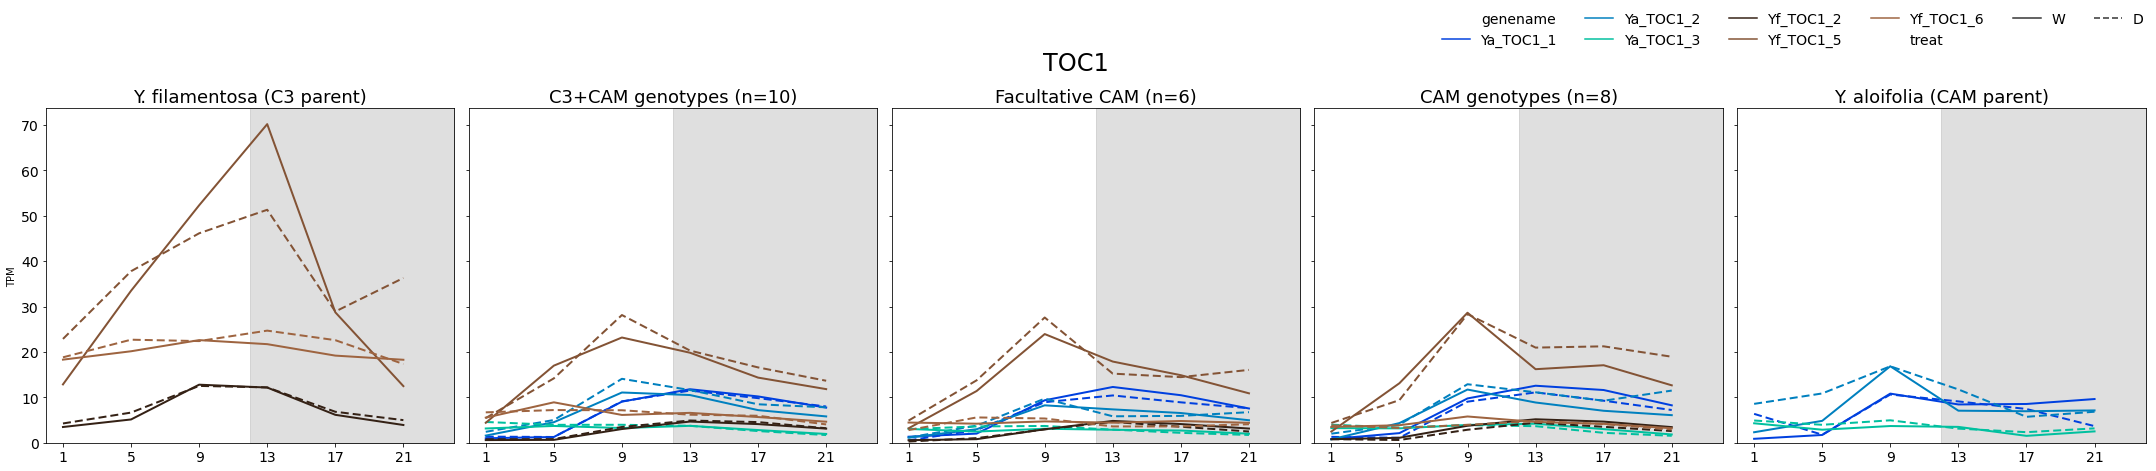

In [62]:
plot_genefam_withparents("TOC1","./circadian_light_profiles")

In [63]:
direc = "./circadian_light_profiles/"

In [66]:
gene_info_2["gene_name"].unique()

array(['TOC1', 'LNK2', 'CCA1/LHY', 'PRR9/PRR5', 'PRR7', 'LUX', 'ELF3',
       'EID1', 'GI'], dtype=object)

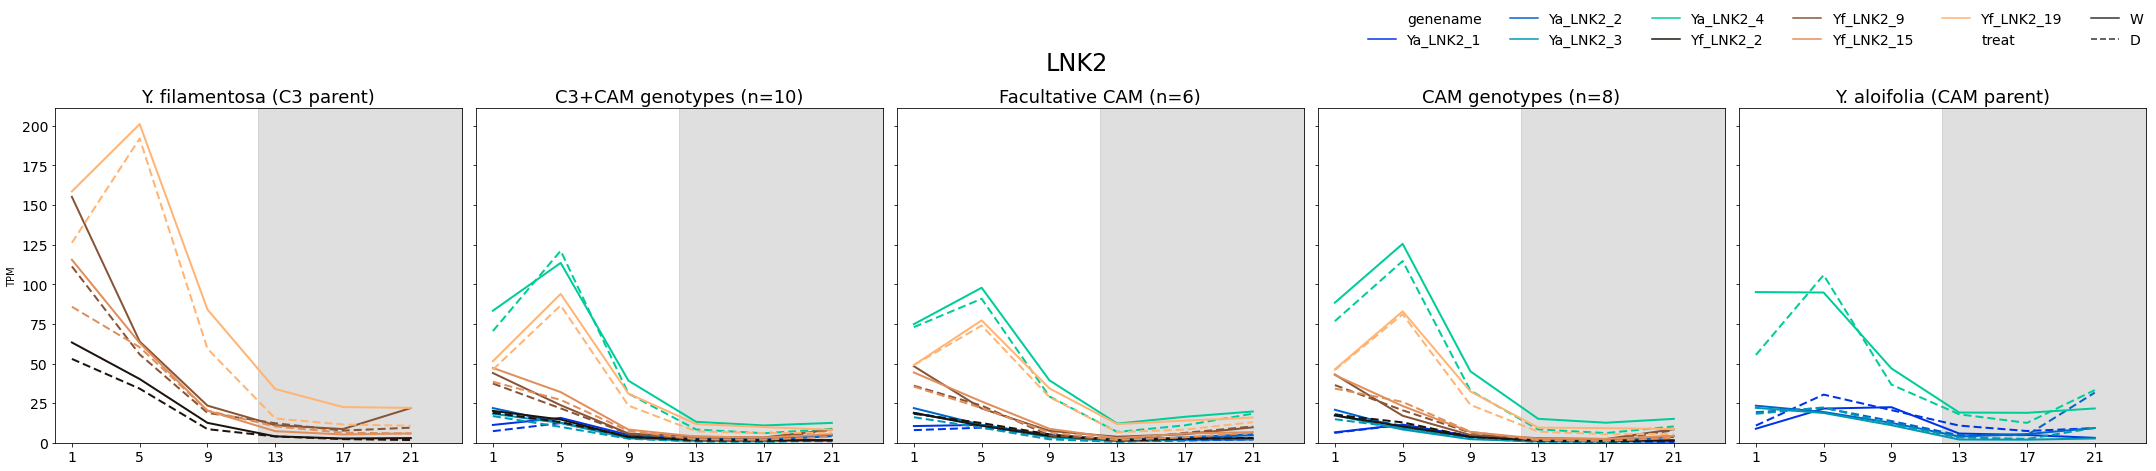

In [67]:
plot_genefam_withparents("LNK2",direc)

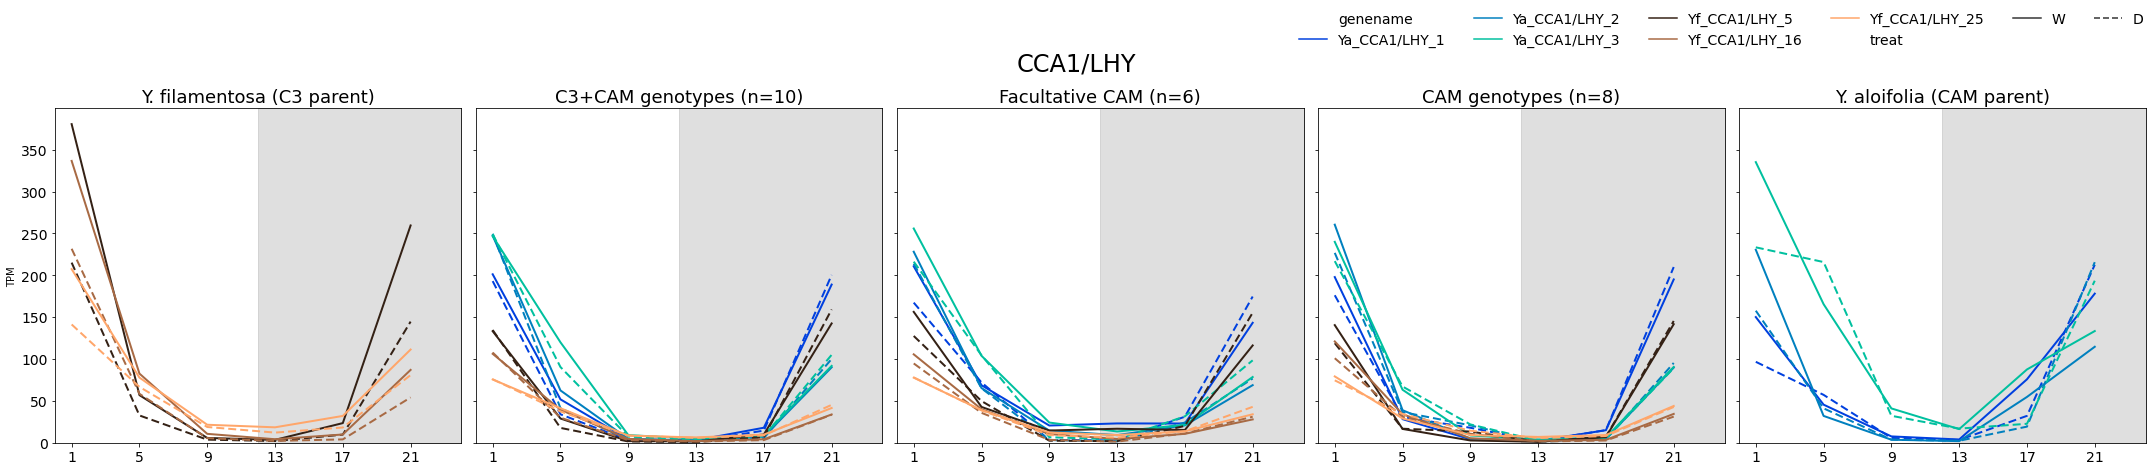

In [70]:
plot_genefam_withparents("CCA1/LHY",direc)

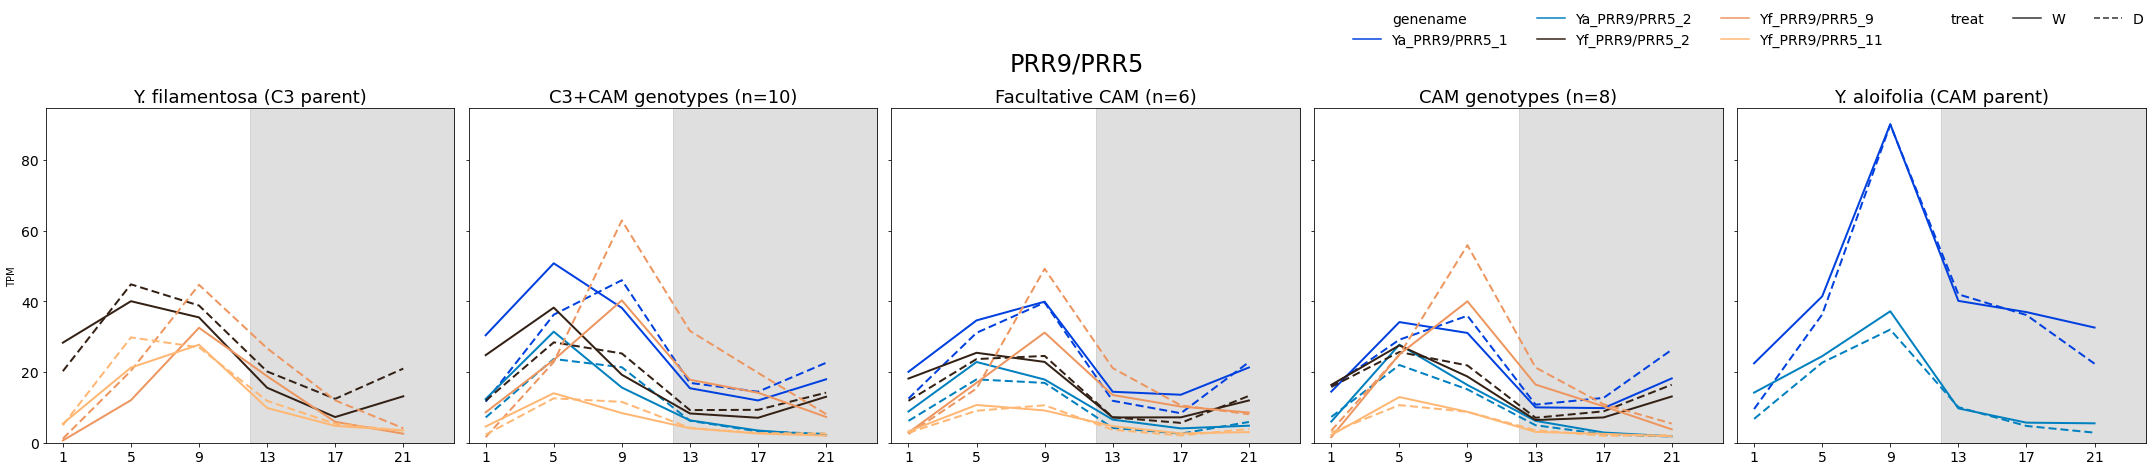

In [71]:
plot_genefam_withparents("PRR9/PRR5",direc)

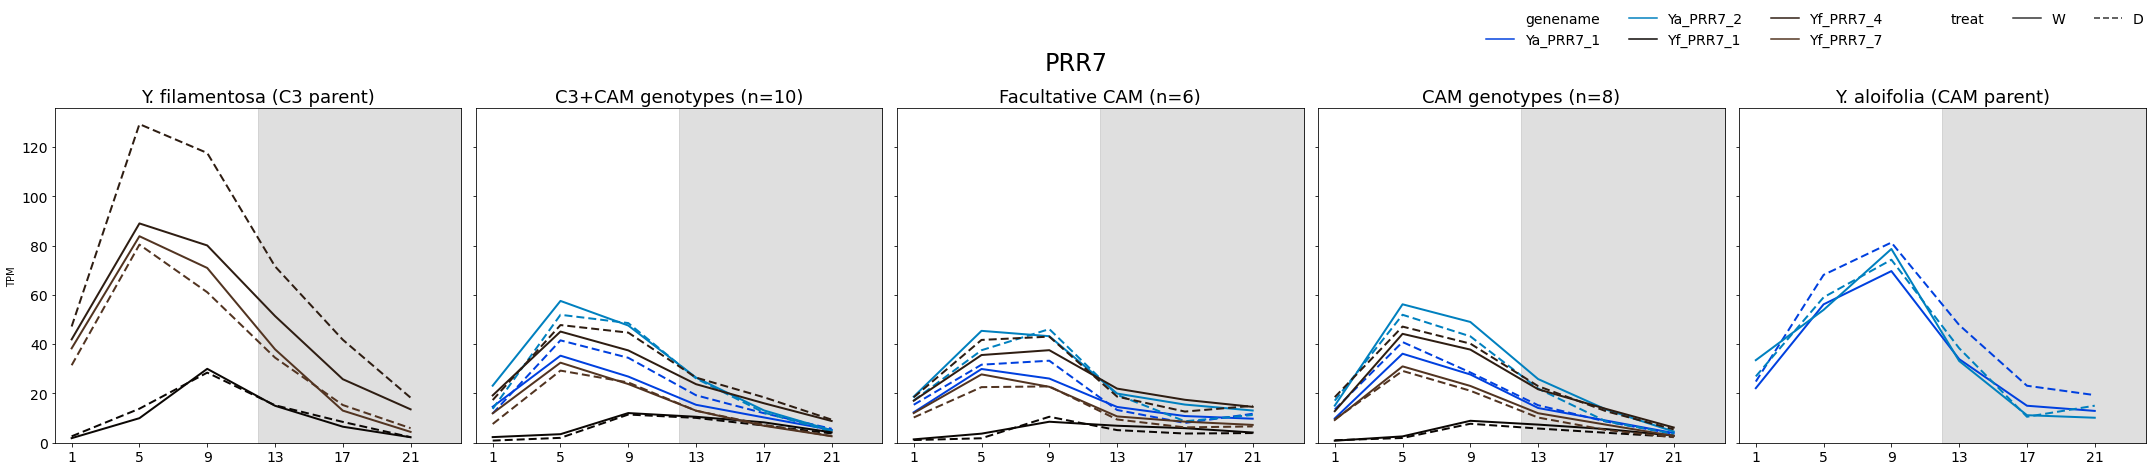

In [72]:
plot_genefam_withparents("PRR7",direc)

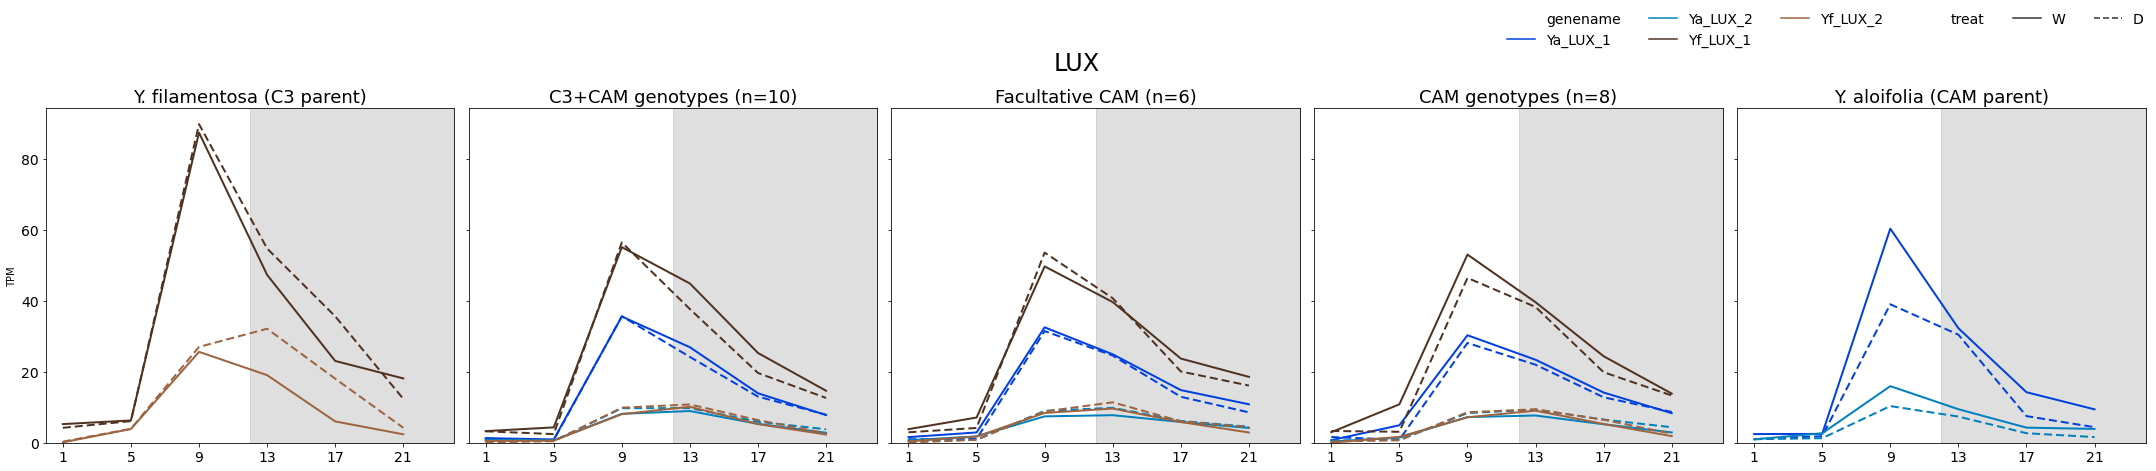

In [73]:
plot_genefam_withparents("LUX",direc)

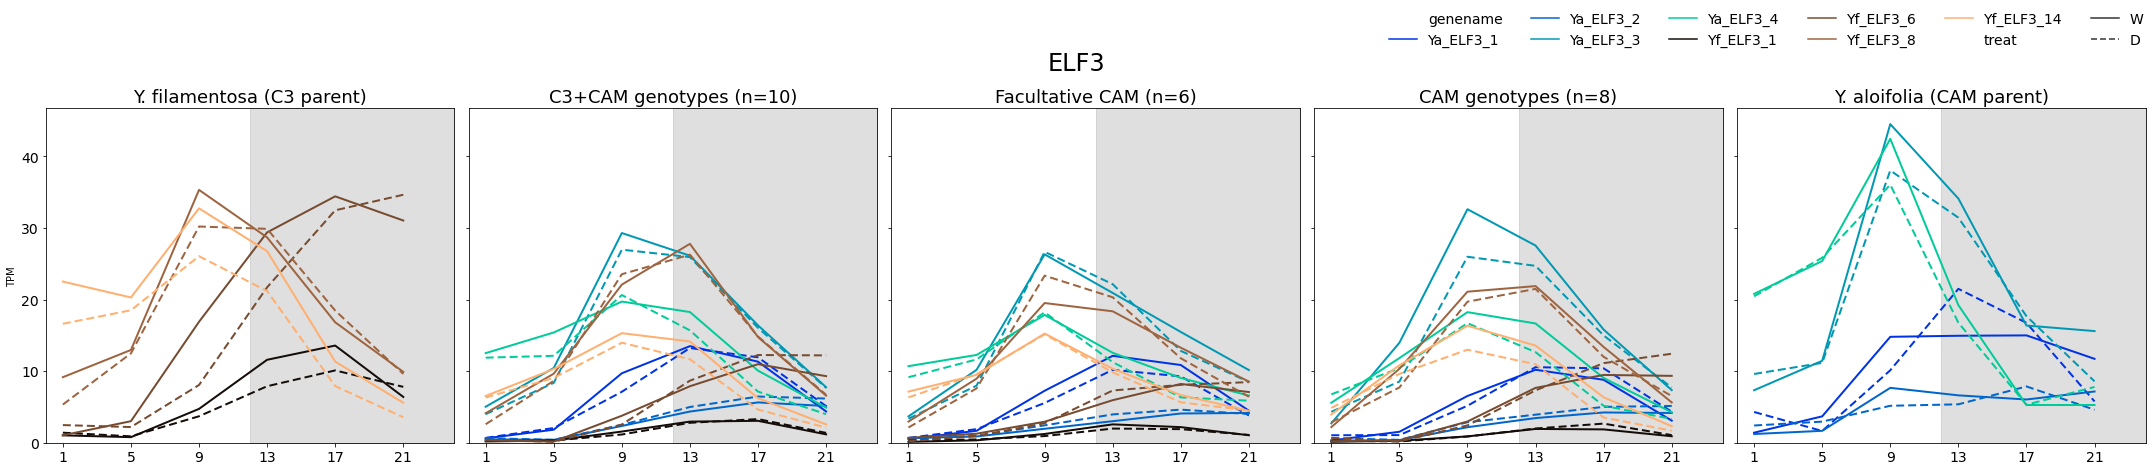

In [74]:
plot_genefam_withparents("ELF3",direc)

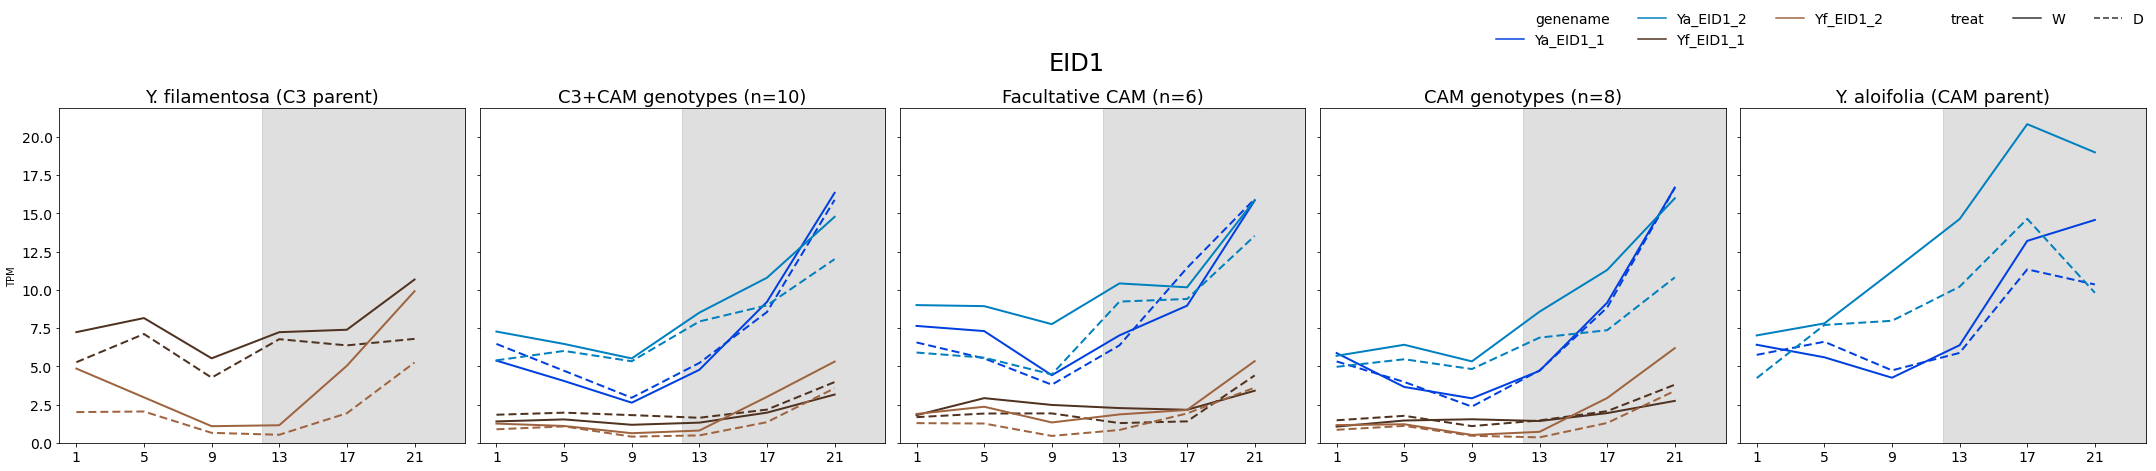

In [75]:
plot_genefam_withparents("EID1",direc)

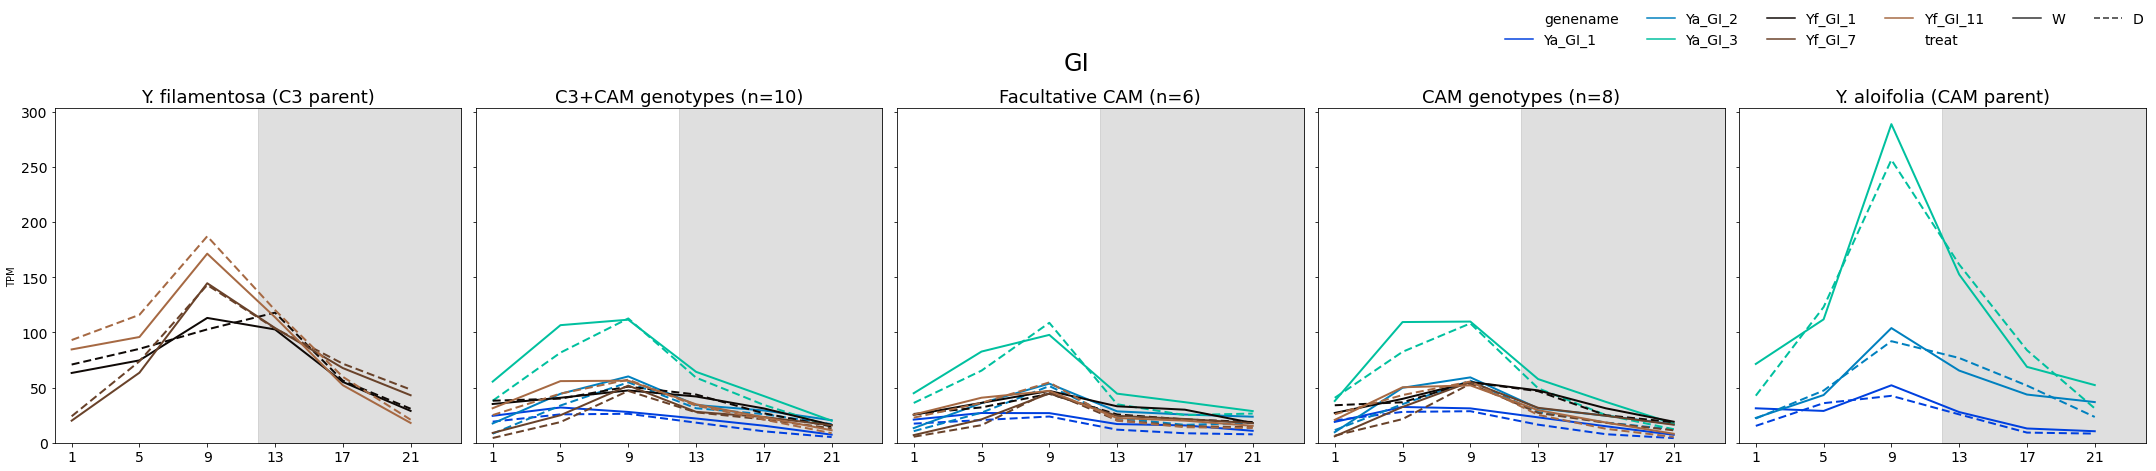

In [76]:
plot_genefam_withparents("GI",direc)

In [77]:
gene_info_2[gene_info_2["GeneID"]=="YufilH1082582m.g"]

,GeneID,Orthogroup,gene_name,subgenome,gene_name_unique
13,YufilH1082582m.g,OG0002589,ELF3,Yf,Yf_ELF3_14


## Section 3: Are these genes time-structured, DE, GDE, ASE?

In [79]:
# load TS gene dataframes 
c3cam = pd.read_csv("./masigpro/C3+CAM_TSgenes_9gt.txt",sep="\t",header="infer")
cam = pd.read_csv("./masigpro/CAM_TSgenes_9gt.txt",sep="\t",header="infer")
faccam = pd.read_csv("./masigpro/facCAM_TSgenes_9gt.txt",sep="\t",header="infer")
yats = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/Ya_hclust_k6_clusters.txt",
                  sep="\t",header="infer")
yfts = pd.read_csv("./masigpro/Yf_3reps_masigpro_clusters.txt",
                  sep="\t",header="infer")

In [92]:
cam.head()

,GeneID,subgenome,physiology
0,Yucal.12G110700.v2.1,Ya,CAM
1,YufilH1093583m.g,Yf,CAM
2,Yucal.04G084700.v2.1,Ya,CAM
3,Yucal.10G075200.v2.1,Ya,CAM
4,Yucal.03G222100.v2.1,Ya,CAM


In [94]:
yats.head()

,cluster,GeneID
0,1,Yucal.01G000500.v2.1
1,2,Yucal.01G000900.v2.1
2,3,Yucal.01G001300.v2.1
3,3,Yucal.01G001400.v2.1
4,4,Yucal.01G002500.v2.1


In [95]:
# add some columns & stick TS gene dataframes together
cam["species"] = "Y. gloriosa"
c3cam["species"] = "Y. gloriosa"
faccam["species"] = "Y. gloriosa"

yats.drop("cluster",axis=1,inplace=True)
yats["subgenome"] = "Ya"
yats["physiology"] = "CAM"
yats["species"] = "Y. aloifolia"

yfts.drop("cluster",axis=1,inplace=True)
yfts["subgenome"] = "Yf"
yfts["physiology"] = "C3"
yfts["species"] = "Y. filamentosa"

In [97]:
all_ts = pd.concat([cam,c3cam,faccam,yats,yfts])

In [98]:
ts_circ = all_ts.merge(gene_info_2)
ts_circ.head()

,GeneID,subgenome,physiology,species,Orthogroup,gene_name,gene_name_unique
0,YufilH1081253m.g,Yf,CAM,Y. gloriosa,OG0002802,PRR9/PRR5,Yf_PRR9/PRR5_11
1,YufilH1081253m.g,Yf,C3+CAM,Y. gloriosa,OG0002802,PRR9/PRR5,Yf_PRR9/PRR5_11
2,YufilH1081253m.g,Yf,C3,Y. filamentosa,OG0002802,PRR9/PRR5,Yf_PRR9/PRR5_11
3,YufilH1070996m.g,Yf,CAM,Y. gloriosa,OG0002802,PRR9/PRR5,Yf_PRR9/PRR5_9
4,YufilH1070996m.g,Yf,C3+CAM,Y. gloriosa,OG0002802,PRR9/PRR5,Yf_PRR9/PRR5_9


In [100]:
ts_circ.sort_values(by=["gene_name_unique","species","physiology"],inplace=True)

In [142]:
# save to a file
ts_circ.to_csv("./circadian_light_profiles/circ_light_TS_genes.csv",sep=",",header=True,index=False)

In [107]:
# summarize
tsc_sum = ts_circ.groupby(["gene_name","species","physiology"]).count().reset_index()[["gene_name","species","physiology","GeneID"]]

In [108]:
tsc_sum.rename(columns={"GeneID":"n_TSGs","gene_name":"gene_family"},inplace=True)

In [109]:
tsc_sum.head()

,gene_family,species,physiology,n_TSGs
0,CCA1/LHY,Y. aloifolia,CAM,1
1,CCA1/LHY,Y. filamentosa,C3,3
2,CCA1/LHY,Y. gloriosa,C3+CAM,4
3,CCA1/LHY,Y. gloriosa,CAM,4
4,CCA1/LHY,Y. gloriosa,facultative_CAM,4


In [110]:
tsc_sum.to_csv("./circadian_light_profiles/circ_light_TSGs_summary.csv",sep=",",header=True,index=False)

In [111]:
# look into GDE results
## first, load GDE results
gde = pd.read_csv("./differential_expression/expression_partitioning_downstream/hybexp_top30pct_partitiongenes_bygttreat.txt",
                    sep="\t",header="infer")
gde.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [113]:
# load synteny info
synlong = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",
                     header="infer")

In [116]:
cinfo = synlong.merge(gene_info_2)
cinfo.head()

,GeneID,syntelogID,Orthogroup,gene_name,subgenome,gene_name_unique
0,YufilH1002012m.g,recip_syn767,OG0002589,ELF3,Yf,Yf_ELF3_2
1,Yucal.01G088400.v2.1,recip_syn767,OG0002589,ELF3,Ya,Ya_ELF3_1
2,YufilH1004830m.g,recip_syn1752,OG0001574,LNK2,Yf,Yf_LNK2_2
3,Yucal.01G204800.v2.1,recip_syn1752,OG0001574,LNK2,Ya,Ya_LNK2_1
4,YufilH1005866m.g,recip_syn2114,OG0009221,EID1,Yf,Yf_EID1_1


In [131]:
gde_circ = gde.rename(columns={"Gene":"syntelogID"})[["syntelogID","Class","genotype_treat"]].merge(cinfo.drop("GeneID",axis=1))

In [132]:
gde_circ.head()

,syntelogID,Class,genotype_treat,Orthogroup,gene_name,subgenome,gene_name_unique
0,recip_syn20301,ADD,18_D,OG0001046,PRR7,Yf,Yf_PRR7_4
1,recip_syn20301,ADD,18_D,OG0001046,PRR7,Ya,Ya_PRR7_1
2,recip_syn20301,ELD_P2,2AB_D,OG0001046,PRR7,Yf,Yf_PRR7_4
3,recip_syn20301,ELD_P2,2AB_D,OG0001046,PRR7,Ya,Ya_PRR7_1
4,recip_syn20301,ELD_P2,1AB_D,OG0001046,PRR7,Yf,Yf_PRR7_4


In [133]:
# split genotype & treatment cols
gde_circ["genotype"] = gde_circ["genotype_treat"].str.split("_").str[0]
gde_circ["treatment"] = gde_circ["genotype_treat"].str.split("_").str[1]

In [134]:
# add physiology info
gde_circ["physiology"] = gde_circ["genotype"].map(phys)
gde_circ.head()

,syntelogID,Class,genotype_treat,Orthogroup,gene_name,subgenome,gene_name_unique,genotype,treatment,physiology
0,recip_syn20301,ADD,18_D,OG0001046,PRR7,Yf,Yf_PRR7_4,18,D,C3+CAM
1,recip_syn20301,ADD,18_D,OG0001046,PRR7,Ya,Ya_PRR7_1,18,D,C3+CAM
2,recip_syn20301,ELD_P2,2AB_D,OG0001046,PRR7,Yf,Yf_PRR7_4,2AB,D,C3+CAM
3,recip_syn20301,ELD_P2,2AB_D,OG0001046,PRR7,Ya,Ya_PRR7_1,2AB,D,C3+CAM
4,recip_syn20301,ELD_P2,1AB_D,OG0001046,PRR7,Yf,Yf_PRR7_4,1AB,D,C3+CAM


In [135]:
gde_circ.sort_values(by=["gene_name_unique","physiology","treatment"],inplace=True)

In [136]:
gde_circ.head()

,syntelogID,Class,genotype_treat,Orthogroup,gene_name,subgenome,gene_name_unique,genotype,treatment,physiology
829,recip_syn2114,UP,2AB_D,OG0009221,EID1,Ya,Ya_EID1_1,2AB,D,C3+CAM
831,recip_syn2114,UP,1AB_D,OG0009221,EID1,Ya,Ya_EID1_1,1AB,D,C3+CAM
833,recip_syn2114,UP,19_D,OG0009221,EID1,Ya,Ya_EID1_1,19,D,C3+CAM
837,recip_syn2114,UP,36_D,OG0009221,EID1,Ya,Ya_EID1_1,36,D,C3+CAM
841,recip_syn2114,UP,45_D,OG0009221,EID1,Ya,Ya_EID1_1,45,D,C3+CAM


In [137]:
gde_circ.drop("genotype_treat",axis=1,inplace=True)
gde_circ.to_csv("./circadian_light_profiles/circ_GDE-HybExp.csv",sep=",",header=True,index=False)

In [139]:
# summarize results
gde_sum = gde_circ.groupby(["gene_name","physiology","treatment","Class"]).count().reset_index()[["gene_name","physiology","treatment","Class","syntelogID"]]


In [140]:
gde_sum.rename(columns={"syntelogID":"n_GDE_genes","gene_name":"gene_family"},inplace=True)
gde_sum.head()

,gene_family,physiology,treatment,Class,n_GDE_genes
0,EID1,C3+CAM,D,ELD_P1,8
1,EID1,C3+CAM,D,UP,24
2,EID1,C3+CAM,W,DOWN,12
3,EID1,C3+CAM,W,UP,6
4,EID1,CAM,D,ELD_P1,8


In [141]:
gde_sum.to_csv("./circadian_light_profiles/circ_light_GDE-HybExp_summary.csv",sep=",",header=True,index=False)

In [151]:
# Jun 23, 2026
# load ASE results
ase = pd.read_csv("./differential_expression/ASE_gttreat_output.txt",sep="\t",header="infer")
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa
1,207.226297,-0.485237,0.071331,-6.802606,1.027436e-11,3.495057e-11,recip_syn3,18_W_aloifolia-V-18_W_filamentosa
2,43.434762,0.344017,0.106880,3.218711,1.287680e-03,2.321305e-03,recip_syn4,18_W_aloifolia-V-18_W_filamentosa
3,52.217998,-1.184873,0.103213,-11.479849,1.665721e-30,1.346501e-29,recip_syn5,18_W_aloifolia-V-18_W_filamentosa
4,390.928299,-0.320654,0.073987,-4.333917,1.464794e-05,3.195546e-05,recip_syn7,18_W_aloifolia-V-18_W_filamentosa


In [153]:
cinfo.head()

,GeneID,syntelogID,Orthogroup,gene_name,subgenome,gene_name_unique
0,YufilH1002012m.g,recip_syn767,OG0002589,ELF3,Yf,Yf_ELF3_2
1,Yucal.01G088400.v2.1,recip_syn767,OG0002589,ELF3,Ya,Ya_ELF3_1
2,YufilH1004830m.g,recip_syn1752,OG0001574,LNK2,Yf,Yf_LNK2_2
3,Yucal.01G204800.v2.1,recip_syn1752,OG0001574,LNK2,Ya,Ya_LNK2_1
4,YufilH1005866m.g,recip_syn2114,OG0009221,EID1,Yf,Yf_EID1_1


In [157]:
circ_ase = ase[["log2FoldChange","GeneID","Contrast"]].rename(columns={"GeneID":"syntelogID"}).merge(cinfo.drop(["GeneID"],axis=1))